In [81]:
import os
import pandas as pd
import numpy as np
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [82]:
BASE_PATH = "/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/"

DATA_PATH = "/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/mnist-bengali/samples"

TRAIN_CSV = "/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/train.csv"
TEST_CSV = "/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/train.csv"
IMG_PATH = "/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/mnist-bengali/samples"

In [83]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print(train_df.head())
print("Train size:", len(train_df))
print("Test size:", len(test_df))

             filename  digit
0  s_03259_a03259.png      3
1  s_12611_a12611.png      6
2  s_26403_c06342.png      6
3  s_50889_e06530.png      3
4  s_28513_c08452.png      7
Train size: 36682
Test size: 36682


In [84]:
class BengaliDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # Improve contrast (important)
        image = cv2.equalizeHist(image)

        # Resize
        image = cv2.resize(image, (64, 64))

        # Convert to 3 channels
        image = np.stack([image]*3, axis=-1)

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image, img_name

        label = self.df.iloc[idx]['digit']
        return image, label

In [85]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

valid_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [86]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df['digit'],
    random_state=42
)

In [87]:
IMG_PATH = "/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/mnist-bengali/samples"

train_dataset = BengaliDataset(train_df, IMG_PATH, train_transform)
val_dataset = BengaliDataset(val_df, IMG_PATH, valid_transform)
test_dataset = BengaliDataset(test_df, IMG_PATH, valid_transform, is_test=True)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
print("okki loaded!")

okki loaded!


In [88]:
import torch.nn.functional as F
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 64 → 32
        x = self.pool(F.relu(self.conv2(x)))  # 32 → 16
        x = self.pool(F.relu(self.conv3(x)))  # 16 → 8

        x = x.view(x.size(0), -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [89]:
model = CustomCNN()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [90]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [91]:
def train_fn(loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [92]:
from sklearn.metrics import f1_score

def eval_fn(loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)

            pred = torch.argmax(outputs, dim=1).cpu().numpy()
            preds.extend(pred)
            targets.extend(labels.numpy())

    return f1_score(targets, preds, average='macro')

In [93]:
best_f1 = 0

for epoch in range(15):   # more epochs for better accuracy
    train_loss = train_fn(train_loader)
    val_f1 = eval_fn(val_loader)

    print(f"Epoch {epoch+1}: Loss={train_loss:.4f}, F1={val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pth")
        print("model saved !!")

Epoch 1: Loss=1.0878, F1=0.8969
Epoch 2: Loss=0.4577, F1=0.9370
Epoch 3: Loss=0.3355, F1=0.9482
Epoch 4: Loss=0.2771, F1=0.9533
Epoch 5: Loss=0.2380, F1=0.9665
Epoch 6: Loss=0.2200, F1=0.9646
Epoch 7: Loss=0.1981, F1=0.9664
Epoch 8: Loss=0.1823, F1=0.9697
Epoch 9: Loss=0.1637, F1=0.9741
Epoch 10: Loss=0.1576, F1=0.9733
Epoch 11: Loss=0.1530, F1=0.9741
Epoch 12: Loss=0.1485, F1=0.9708
Epoch 13: Loss=0.1417, F1=0.9774
Epoch 14: Loss=0.1366, F1=0.9742
Epoch 15: Loss=0.1314, F1=0.9735


In [94]:
import pandas as pd

test_df = pd.read_csv("/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/sample_submission.csv")

print(test_df.head())

             filename  digit
0  s_09719_a09719.png      1
1  s_03018_a03018.png      1
2  s_29506_c09445.png      1
3  s_14500_a14500.png      1
4  s_37649_c17588.png      1


In [95]:
test_dataset = BengaliDataset(
    test_df,
    IMG_PATH,   
    valid_transform,
    is_test=True
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [96]:
model = CustomCNN().to(device)
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.eval()

CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [97]:
predictions = []
filenames = []

with torch.no_grad():
    for images, names in test_loader:
        images = images.to(device)
        outputs = model(images)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        predictions.extend(preds)
        filenames.extend(names)

In [98]:
test_df["digit"] = predictions
test_df.to_csv("submission.csv", index=False)

print("✅ submission.csv created!")

✅ submission.csv created!


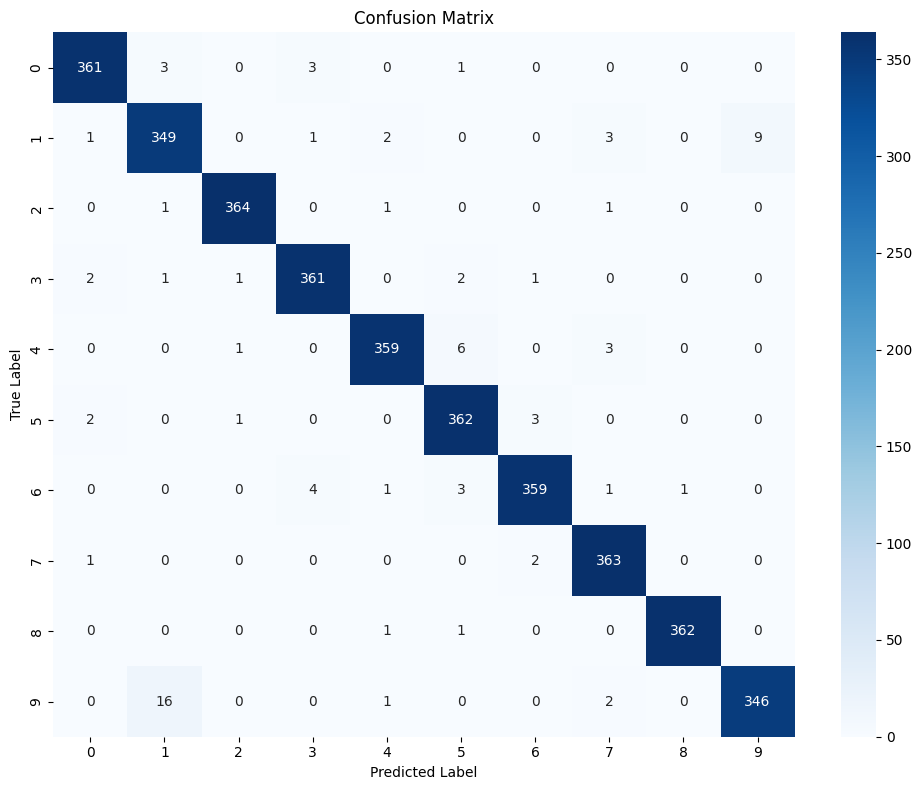

In [123]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader, device, class_names=None, normalize=False):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Normalize if needed
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, 
                annot=True, 
                fmt=".2f" if normalize else "d", 
                cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))

    plt.tight_layout()
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = [str(i) for i in range(10)]  # for digit classification

plot_confusion_matrix(model, val_loader, device, class_names)

In [124]:
from sklearn.metrics import classification_report
import torch

def get_classification_report(model, loader, device, class_names=None):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )

    print(report)

In [125]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = [str(i) for i in range(10)]

get_classification_report(model, val_loader, device, class_names)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       368
           1       0.94      0.96      0.95       365
           2       0.99      0.99      0.99       367
           3       0.98      0.98      0.98       368
           4       0.98      0.97      0.98       369
           5       0.97      0.98      0.97       368
           6       0.98      0.97      0.98       369
           7       0.97      0.99      0.98       366
           8       1.00      0.99      1.00       364
           9       0.97      0.95      0.96       365

    accuracy                           0.98      3669
   macro avg       0.98      0.98      0.98      3669
weighted avg       0.98      0.98      0.98      3669

